## CASE STUDY: Group 1

In [1]:
# Case Study: Does Annual Household Income Play a Role in Minority's Political Party Identification?
# Data: British Election Study - Ethnic Minority Survey 2010

import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

df, meta = pyreadstat.read_dta('BSE_2010.dta')

In [2]:
#Income categories (zqinc) and party categories (bq9_1). Two categorical variables. Chi-square is the right test.

Step 1: Cleaning

In [3]:
# Cleaning the data: we keep only valid responses removing -1 and -2 (don't know and refused) for both variables. .

df_clean = df[(df['zqinc'] > 0) & (df['bq9_1'] > 0)].copy()

#the data is encoded with numbers. we use variable_value_labels to decode the numbers into readable labels.
# readable labels
income_labels = meta.variable_value_labels['zqinc']
party_labels = meta.variable_value_labels['bq9_1']


# this step maps each numeric code to its text label by creating two new columns.
# 'income_label' translates zqinc codes (e.g. 3 → '10001-15000')
# 'party_label' translates bq9_1 codes (e.g. 2 → 'Labour'). 
df_clean['income_label'] = df_clean['zqinc'].map(income_labels) 
df_clean['party_label'] = df_clean['bq9_1'].map(party_labels)

print(f"Original sample: {len(df)} respondents")
print(f"Clean sample: {len(df_clean)} respondents")
print(f"Removed: {len(df) - len(df_clean)} respondents with 'dont know' and 'refused' responses")

Original sample: 2787 respondents
Clean sample: 1597 respondents
Removed: 1190 respondents with 'dont know' and 'refused' responses


Step 2: Build the contingency table


In [4]:
# Rows = income bands, Columns = political parties
# Each cell shows how many people fall in that combination

contingency_table = pd.crosstab(
    df_clean['income_label'],
    df_clean['party_label']
)

print(contingency_table)

party_label    British National Party (BNP)  \
income_label                                  
0 - 5000                                  1   
10001- 15000                              1   
15001 - 20000                             0   
20001 - 25000                             0   
25001 - 30000                             0   
30001 - 35000                             0   
35001 - 40000                             0   
41000 - 45000                             0   
45001 - 50000                             0   
50001 - 60000                             0   
5001 - 10000                              1   
60001 - 70000                             0   
70001 - 80000                             0   
80001 or more                             0   

party_label    Coalition party/Conservative-Lib dem party  Conservatives  \
income_label                                                               
0 - 5000                                                0             11   
10001- 15000       

Step 3: Simplify party categories


In [5]:
# Parties with very few respondents can be grouped as 'Other'
# This is necessary for chi-square assumptions
#(EXPLAINATION)
# Several parties (BNP, UKIP, SNP, Respect etc.) have very few respondents.
# When cells have fewer than 5 observations, the test can be unreliable.
# to solve this, we can group all small parties into a single 'Other' category so the observations are more evenly distributed.
# We keep the 4 main parties that have enough respondents.

party_order = ['Labour', 'Conservatives', 'Liberal Democrats', 'None/No', 'Other']

df_clean['party_grouped'] = df_clean['party_label'].apply(
    lambda x: x if x in party_order[:-1] else 'Other'
)

# Ordinal variable ordering: since these are text strings, we still want to sort them numerically so we manaully define the correct order. 
income_order = [
    '0 - 5000', '5001 - 10000', '10001- 15000', '15001 - 20000',
    '20001 - 25000', '25001 - 30000', '30001 - 35000', '35001 - 40000',
    '41000 - 45000', '45001 - 50000', '50001 - 60000',
    '60001 - 70000', '70001 - 80000', '80001 or more'
]

df_clean['income_label'] = pd.Categorical(
    df_clean['income_label'], 
    categories=income_order, 
    ordered=True
)

# Rebuild contingency table
contingency_table = pd.crosstab(
    df_clean['income_label'],
    df_clean['party_grouped']
)

print(contingency_table)

party_grouped  Conservatives  Labour  Liberal Democrats  None/No  Other
income_label                                                           
0 - 5000                  11      99                 15       23      4
5001 - 10000              19     203                 24       31      6
10001- 15000              16     180                 27       28      8
15001 - 20000             13     132                 17       26      2
20001 - 25000             14      84                 14       11      3
25001 - 30000             17      85                  9       10      2
30001 - 35000              8      51                 13        8      1
35001 - 40000             13      56                 11       15      1
41000 - 45000              2      37                  5        4      0
45001 - 50000              6      21                  9        6      0
50001 - 60000              9      40                  3        5      0
60001 - 70000              7      19                  1        6

Step 4: Running The chi-square test

In [6]:
# Chi-square tests whether two categorical variables are independent of each other.

# H0 (null hypothesis): Income and party identification are independent
# H1 (alternative hypothesis): Income and party identification are associated

# We reject H0 if p-value < 0.05 (standard significance threshold)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom:   {dof}")
print(f"P-value:              {p:.4f}")
print(f"\nConclusion:")
if p < 0.05:
    print(f"p = {p:.4f} < 0.05 → We REJECT the null hypothesis.")
    print("There IS a statistically significant association between income and party identification.")
else:
    print(f"p = {p:.4f} > 0.05 → We FAIL TO REJECT the null hypothesis.")
    print("There is NO statistically significant association between income and party identification.")

Chi-square statistic: 69.0388
Degrees of freedom:   52
P-value:              0.0570

Conclusion:
p = 0.0570 > 0.05 → We FAIL TO REJECT the null hypothesis.
There is NO statistically significant association between income and party identification.


Step 5: Check chi-square assumptions

(Since p is not reliable to establish a hypothesis quite apparent from the contingency table, we need to reassess the reliability of our chi_square contingency table)

In [7]:
# Chi-square requires expected frequency >= 5 in each cell

#Source: Intenret-> "Adequate Expected Frequencies: At least 80% of cells must have an expected value of 5 or greater, and no cell can have an expected value less than 1)""

# If too many cells violate this, our result may be unreliable

chi2, p, dof, expected = chi2_contingency(contingency_table)

expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

cells_below_5 = (expected_df < 5).sum().sum()
total_cells = expected_df.size
percentage_below = (cells_below_5 / total_cells) * 100

print(f"Cells with expected frequency < 5: {cells_below_5} out of {total_cells}")
print(f"Percentage: {percentage_below:.1f}%")
print(f"\nRule: No more than 20% of cells should be below 5")

if percentage_below > 20:
    print("We need to combine income bands to reduce this percentage.")
else:
    print("Assumption satisfied.")

Cells with expected frequency < 5: 24 out of 70
Percentage: 34.3%

Rule: No more than 20% of cells should be below 5
We need to combine income bands to reduce this percentage.


Step 6: Rerun chi-square with grouped income bands


In [8]:
# This addresses the assumption violation we identified in Step 5
# Grouping income into 4 broader bands ensures expected frequencies are sufficient

def group_income(income):
    if income in ['0 - 5000', '5001 - 10000', '10001- 15000', '15001 - 20000']:
        return '1. Low (under £20k)'
    elif income in ['20001 - 25000', '25001 - 30000', '30001 - 35000']:
        return '2. Lower-middle (£20k-£35k)'
    elif income in ['35001 - 40000', '41000 - 45000', '45001 - 50000', '50001 - 60000']:
        return '3. Upper-middle (£35k-£60k)'
    else:
        return '4. High (over £60k)'

df_clean['income_grouped'] = df_clean['income_label'].apply(group_income)

contingency_table2 = pd.crosstab(
    df_clean['income_grouped'],
    df_clean['party_grouped']
)

print(contingency_table2)

party_grouped                Conservatives  Labour  Liberal Democrats  \
income_grouped                                                          
1. Low (under £20k)                     59     614                 83   
2. Lower-middle (£20k-£35k)             39     220                 36   
3. Upper-middle (£35k-£60k)             30     154                 28   
4. High (over £60k)                     25      78                 12   

party_grouped                None/No  Other  
income_grouped                               
1. Low (under £20k)              108     20  
2. Lower-middle (£20k-£35k)       29      6  
3. Upper-middle (£35k-£60k)       30      1  
4. High (over £60k)               23      2  


Step 7: Run chi-square test on grouped income bands


In [9]:
# This is our main result - grouping fixes the assumption violation

chi2, p, dof, expected = chi2_contingency(contingency_table2)

# Check assumption with new table
expected_df2 = pd.DataFrame(
    expected,
    index=contingency_table2.index,
    columns=contingency_table2.columns
)

cells_below_5 = (expected_df2 < 5).sum().sum()
total_cells = expected_df2.size
percentage_below = (cells_below_5 / total_cells) * 100

print(f"Assumption check:")
print(f"Cells below 5: {cells_below_5} out of {total_cells} ({percentage_below:.1f}%)")
print()
print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom:   {dof}")
print(f"P-value:              {p:.5f}")
print()
if p < 0.05:
    print(f"p = {p:.5f} < 0.05 → We REJECT the null hypothesis.")
    print("There IS a statistically significant association between income and party identification.")
else:
    print(f"p = {p:.5f} > 0.05 → We FAIL TO REJECT the null hypothesis.")
    print("There is NO statistically significant association between income and party identification.")

Assumption check:
Cells below 5: 2 out of 20 (10.0%)

Chi-square statistic: 35.8038
Degrees of freedom:   12
P-value:              0.00035

p = 0.00035 < 0.05 → We REJECT the null hypothesis.
There IS a statistically significant association between income and party identification.


Step 8: Visualisation


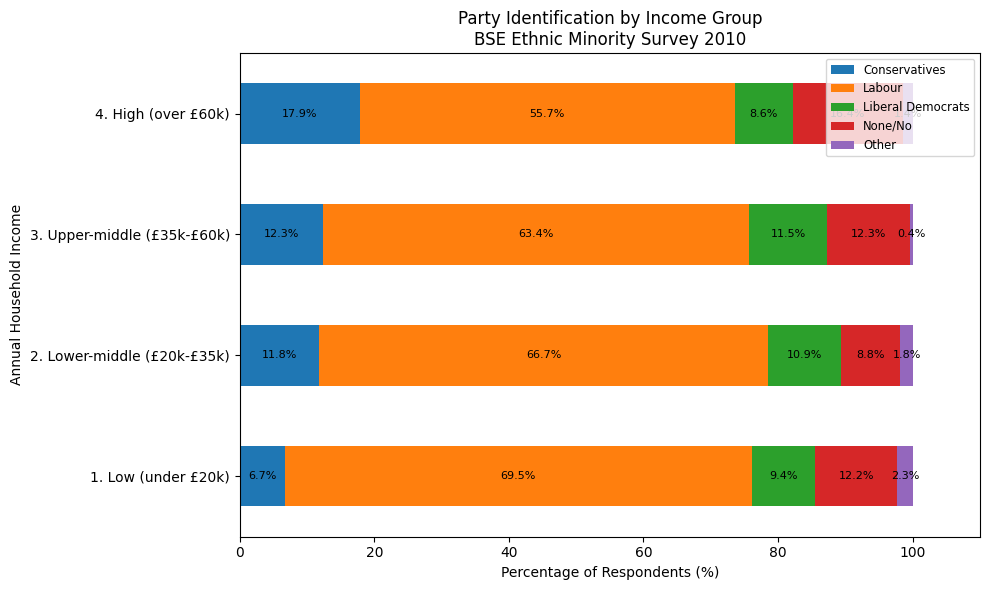

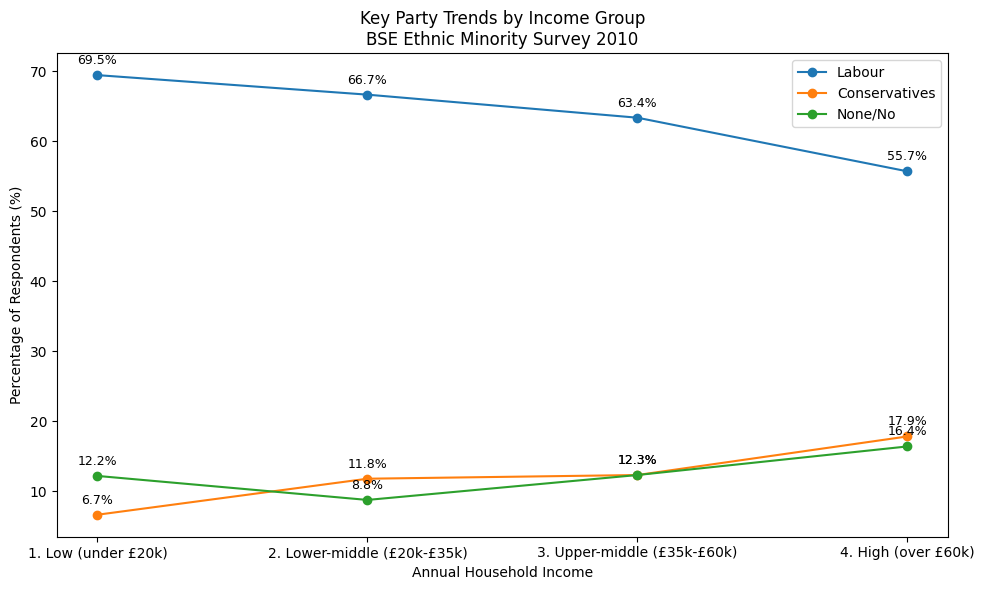

In [10]:

# Convert to percentages
contingency_pct = contingency_table2.div(
    contingency_table2.sum(axis=1), axis=0) * 100

# Chart 1: Stacked bar - shows full party breakdown across income groups
ax = contingency_pct.plot(kind='barh', stacked=True, figsize=(10, 6))
for bar_group in ax.containers:
    ax.bar_label(bar_group, fmt='%.1f%%', label_type='center', fontsize=8)
ax.set_ylabel('Annual Household Income')
ax.set_xlabel('Percentage of Respondents (%)')
ax.set_title('Party Identification by Income Group\nBSE Ethnic Minority Survey 2010')
ax.legend(loc='upper right', fontsize = 'small')
ax.set_xlim(0, 110) #so the end is verifiable

plt.tight_layout()
plt.savefig('party_by_income_stacked.png', dpi=150)
plt.show()

# Chart 2: Line chart - highlights trend direction for key parties
fig, ax = plt.subplots(figsize=(10, 6))
for party in ['Labour', 'Conservatives', 'None/No']:
    ax.plot(contingency_pct.index, contingency_pct[party], marker='o', label=party)
    for i, val in enumerate(contingency_pct[party]):
        ax.annotate(f'{val:.1f}%', (i, contingency_pct[party].iloc[i]),
                    textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=9)
ax.set_xlabel('Annual Household Income')
ax.set_ylabel('Percentage of Respondents (%)')
ax.set_title('Key Party Trends by Income Group\nBSE Ethnic Minority Survey 2010')
ax.legend()
#plt.xticks()
plt.tight_layout()
plt.savefig('party_by_income_trend.png', dpi=150)
plt.show()

Note: We are using percentages and not raw numbers Because the income bands have different numbers of people in them — Low income has 884 people, High income only 140. Raw numbers would be misleading.
Every bar represents 100% of that income group, and we can see the genuine shift in party preference regardless of how many people are in each group.